---

# Mapa de de dicas secos com dados do CPC

---

- `OBJETIVO`:
> Este código calcula e plota mapa de dias secos com dados do CPC para o Brasil para um determinado ano.



- `DADOS DE ENTRADA`:
> Dados globais diários de precipitação do Climate Prediction Center (CPC) com 50km de resolução espacial. Os dados são disponíveis desde 1979 e são carregados diretamente através do Xarray via Protocolo OPeNDAP através do seguinte [link](http://apdrc.soest.hawaii.edu:80/dods/public_data/Interpolated_precipitation/cpc_rainfall/Daily). Mais informações dos dados acesse [aqui](http://apdrc.soest.hawaii.edu/dods/public_data/Interpolated_precipitation/cpc_rainfall/Daily.info) e diversos outros dados disponibilizados pelo Asia-Pacific Data Research Center, acesse [aqui](https://apdrc.soest.hawaii.edu/data/data.php?discipline_index=3).


- `DADOS DE SAÍDA`:
> 1. Mapa em formato JPG do acumulado de precipitação, dias secos e dias secos em porcentagem. Exemplo: `Fig_1_dias_secos_brasil_2024-01-01_a_2024-01-01.jpg`


- `OBSERVAÇÕES`:
   > Nenhuma.

- `REALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026

- `ATUALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026
---


# Prepando ambiente


In [1]:
#=========================================================================================================================#
#                                          INSTALAÇÃO E IMPORTAÇÃO DAS BIBLIOTECAS
#=========================================================================================================================#
# instala bibliotecas
!pip install -q xarray dask netCDF4 bottleneck xclim ultraplot cartopy salem rasterio pyproj geopandas

# importa bibliotecas
import xarray as xr
import xclim as xc
import ultraplot as uplt
import salem
import os
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore")

#=========================================================================================================================#
#                                  MONTA O GOOGLE DRIVE E CRIA O DIRETÓRIO DE SAÍDA
#=========================================================================================================================#
# monta o drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/09_INDICES_CLIMATICOS_XCLIM'

# diretório de saída
dir_output = f'{dir}/output'

# cria pasta de saída
os.makedirs(dir_output, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.7/384.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.7 MB/s eta 0:00:00


Mounted at /content/drive


# Plota figura

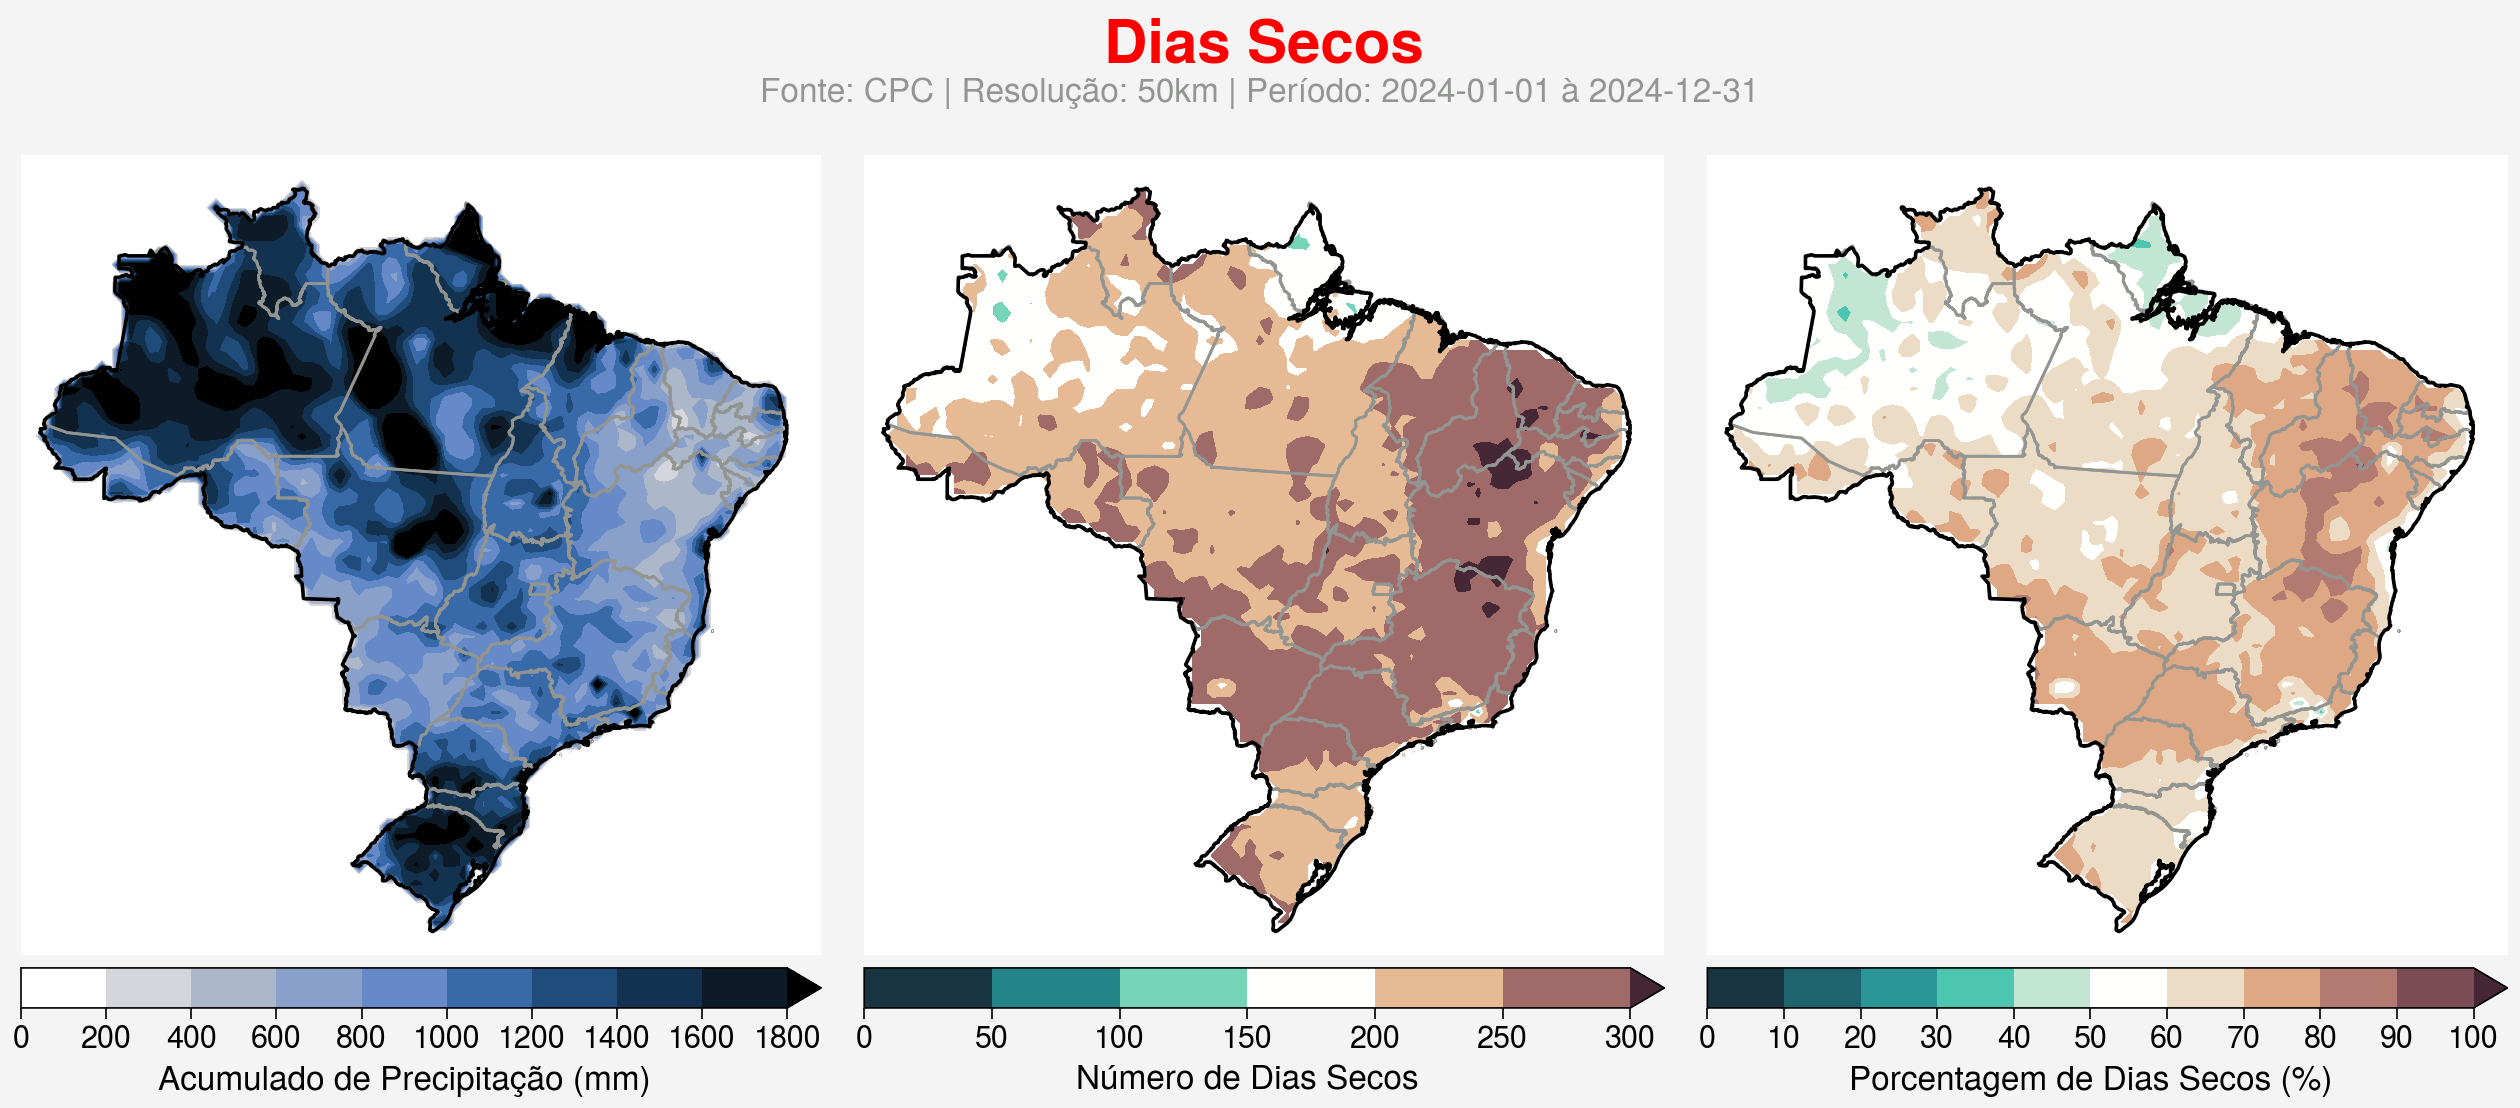

In [2]:
#=========================================================================================================================#
#                                            CARREGA OS DADOS DO CPC
#=========================================================================================================================#
# limites
lonmin, lonmax, latmin, latmax = -53.3, -43.9, -25.4, -19.7 # estado de SP
lonmin, lonmax, latmin, latmax = -75.0, -33.0, -35.0, 7.0 # Brasil

# leitura do shapefile que contêm o contorno do Brasil
shapefile_brasil = salem.read_shapefile('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BRAZIL.shp')

# carrega os dados
cpc_precip_diaria = xr.open_dataset('http://apdrc.soest.hawaii.edu:80/dods/public_data/Interpolated_precipitation/cpc_rainfall/Daily').squeeze()

# transforma as longitudes de 0/360 para -180/+180
cpc_precip_diaria.coords['lon'] = ((cpc_precip_diaria.coords['lon'] + 180) % 360) - 180 ; cpc_precip_diaria = cpc_precip_diaria.sortby(cpc_precip_diaria.lon)

# datas
data_inicial, data_final = '2024-01-01', '2024-12-31'

# seleciona os dados
cpc_precip_diaria = cpc_precip_diaria.sel(lon=slice(lonmin,lonmax), lat=slice(latmin,latmax)).sel(time=slice(data_inicial, data_final))

#=========================================================================================================================#
#                                         CALCULA A QUANTIDADE DE DIAS SECOS
#=========================================================================================================================#
# atribuição de unidade
cpc_precip_diaria['precip'].attrs['units'] = 'mm/d'

# número de dias secos
dry_days_cpc = xc.indices.dry_days(cpc_precip_diaria['precip'], thresh='1.0 mm/d', freq='YS')

# recorta para o Brasil
cpc_precip_diaria = cpc_precip_diaria.salem.roi(shape=shapefile_brasil)
dry_days_cpc = dry_days_cpc.salem.roi(shape=shapefile_brasil)

#=========================================================================================================================#
#                                                  PLOTA MAPA
#=========================================================================================================================#
#------------------------------------------------------------------#
#                    FORMATAÇÃO DA FIGURA
#------------------------------------------------------------------#
# cria a moldura da figura
fig, ax = uplt.subplots(axwidth=4.0, ncols=3, tight=True, proj='pcarree', proj_kw={'lon_0':0})

# parâmetros de formatação dos mapas
ax.format(land=False, coast=False, innerborders=False, borders=False,
          labels=False, latlim=(latmin, latmax), lonlim=(lonmin, lonmax),
          latlines=10, lonlines=10,
          small='20px',  large='30px',
          geogridlinewidth=0,
          suptitle=f'Dias Secos\n',
          suptitle_kw = {'color': 'red', 'fontweight': 'bold'},
          linewidth=0, grid=False)

# subtítulo
fig.text(0.50, 0.93,
         f'Fonte: CPC | Resolução: 50km | Período: {data_inicial} à {data_final}',
         transform=fig.transFigure,
         color='gray',
         fontsize=12,
         ha='center',
         va='top')

# plota contornos dos Estados
shapefile = list(shpreader.Reader('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray', facecolor='none', linewidth=1.0, alpha=1, zorder=2)

# plota contorno do Brasil
shapefile = list(shpreader.Reader('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BRAZIL.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.3, alpha=1, zorder=2)

#------------------------------------------------------------------#
#             FIG-1: ACUMULADO DE PRECIPITAÇÃO
#------------------------------------------------------------------#
# mapa
map1 = ax[0].contourf(cpc_precip_diaria['precip'].sum('time'),
                      levels=uplt.arange(0, 1800, 200),
                      extend='max',
                      cmap='oslo_r')
# barra de cores
ax[0].colorbar(map1, loc='b',
               ticks=uplt.arange(0, 1800, 200),
               label='Acumulado de Precipitação (mm)',
               ticklabelsize=11,
               labelsize=12)

#------------------------------------------------------------------#
#                FIG-2: NÚMERO DE DIAS SECOS
#------------------------------------------------------------------#
# mapa
map2 = ax[1].contourf(dry_days_cpc.where(dry_days_cpc != 0).squeeze(),
                      levels=uplt.arange(0, 300, 50),
                      extend='max',
                      cmap='DryWet_r')

# barra de cores
ax[1].colorbar(map2, loc='b',
               ticks=uplt.arange(0, 300, 50),
               label='Número de Dias Secos',
               ticklabelsize=11,
               labelsize=12)

#------------------------------------------------------------------#
#                FIG-2: NÚMERO DE DIAS SECOS EM %
#------------------------------------------------------------------#
# mapa
map3 = ax[0, 2].contourf((dry_days_cpc.where(dry_days_cpc != 0) / cpc_precip_diaria['time'].shape[0] * 100).squeeze(),
                          levels=uplt.arange(0, 100, 10),
                          extend='max',
                          cmap='DryWet_r')

# barra de cores
ax[0, 2].colorbar(map3,
                  loc='b',
                  ticks=uplt.arange(0, 100, 10),
                  label='Porcentagem de Dias Secos (%)',
                  ticklabelsize=11,
                  labelsize=12)

#------------------------------------------------------------------#
#                        SALVA FIGURA
#------------------------------------------------------------------#
# salva figura
fig.savefig(f'{dir_output}/Fig_1_dias_secos_brasil_{data_inicial}_a_{data_inicial}.jpg', dpi=300, bbox_inches="tight")

In [3]:
# mostra os dados do CPC
cpc_precip_diaria

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 366, lat: 84, lon: 84)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
  * lat      (lat) float64 672B -34.75 -34.25 -33.75 -33.25 ... 5.75 6.25 6.75
  * lon      (lon) float64 672B -74.75 -74.25 -73.75 ... -34.25 -33.75 -33.25
Data variables:
    precip   (time, lat, lon) float32 10MB nan nan nan nan ... nan nan nan nan
Attributes:
    title:          CPC Global Daily Precipitation
    Conventions:    COARDS\nGrADS
    dataType:       Grid
    documentation:  http://apdrc.soest.hawaii.edu/datadoc/cpc_precipday.php
    history:        Fri May 29 23:55:47 HST 2026 : imported by GrADS Data Ser...
    pyproj_srs:     +proj=longlat +datum=WGS84 +no_defs

In [4]:
# mostra o número de dias secos
dry_days_cpc

<xarray.DataArray 'precip' (time: 1, lat: 84, lon: 84)> Size: 56kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 8B 2024-01-01
  * lat      (lat) float64 672B -34.75 -34.25 -33.75 -33.25 ... 5.75 6.25 6.75
  * lon      (lon) float64 672B -74.75 -74.25 -73.75 ... -34.25 -33.75 -33.25
Attributes:
    long_name:   daily total of precipitation [mm] 
    units:       d
    pyproj_srs:  +proj=longlat +datum=WGS84 +no_defs